# 07 · 다중 루프 조율

**구성요소:** 다중 루프 조율(multi-loop coordination).

**핵심 아이디어**

> "저장소 하나에 루프를 둘 이상 돌리는 것은 정상이다. 경계 없이 돌리는 것이 루프들끼리 싸우게 만드는 방법이다."

원칙은 넷이다 — **브랜치마다 소유자 하나**, **상태 파일 분리**, **어떤 수정이든 착수 전에 확인하는 `acting_on` 락**, 그리고 **루프끼리 부딪혔을 때의 우선순위**.

**문제 설정** — 저장소 하나 위에서 루프 3개가 돈다. CI 스위퍼, PR 베이비시터, 의존성 스위퍼다. 각자의 작업 큐는 일부 파일에서 겹친다. 조율이 없으면 세 루프가 같은 시각에 같은 대상을 붙잡고 중복되거나 서로 충돌하는 작업을 한다. 조율 프로토콜 — 각 루프가 공유 `acting_on` 레지스트리에 대상을 클레임하고, 자기보다 높은 우선순위에는 양보하는 규율 — 이 그 충돌을 없앤다.

**측정 대상** — **충돌 건수**(같은 라운드에 두 루프가 같은 대상을 건드린 횟수)와 **낭비된 작업**(중복 실행과 그 토큰 비용). 프로토콜이 없을 때와 있을 때를 나란히 잰다.

**워크트리와 무엇이 다른가** — 이것이 조율의 지표이고, 워크트리의 지표와는 다르다. 워크트리는 루프 **하나 안의** 서브에이전트들을 격리한다. 여기서는 **독립된 루프들 사이**를 조율한다. 05번이 아래층이라면 이 노트북은 그 위층이다.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  실행 환경 (자동 판별)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LLM       : openai    gpt-5.6-luna
              ↳ localhost 무응답 → OPENAI_API_KEY 감지 · 선호 순위표에서 자동 선택 (캐시)
  임베딩    : openai    text-embedding-3-small
              ↳ CUDA 미가용 → API 임베딩 · 기본값 (캐시)
  데이터    : /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/data
  전환      : LLM_PROVIDER=vllm|openai  /  EMBED_PROVIDER=local|openai
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

=========================================== 루프 셋, 저장소 하나 ===========================================


*각 루프가 acting_on 으로 대상을 클레임한다. 동점은 우선순위가 가른다. 브랜치마다 소유자는 하나다*

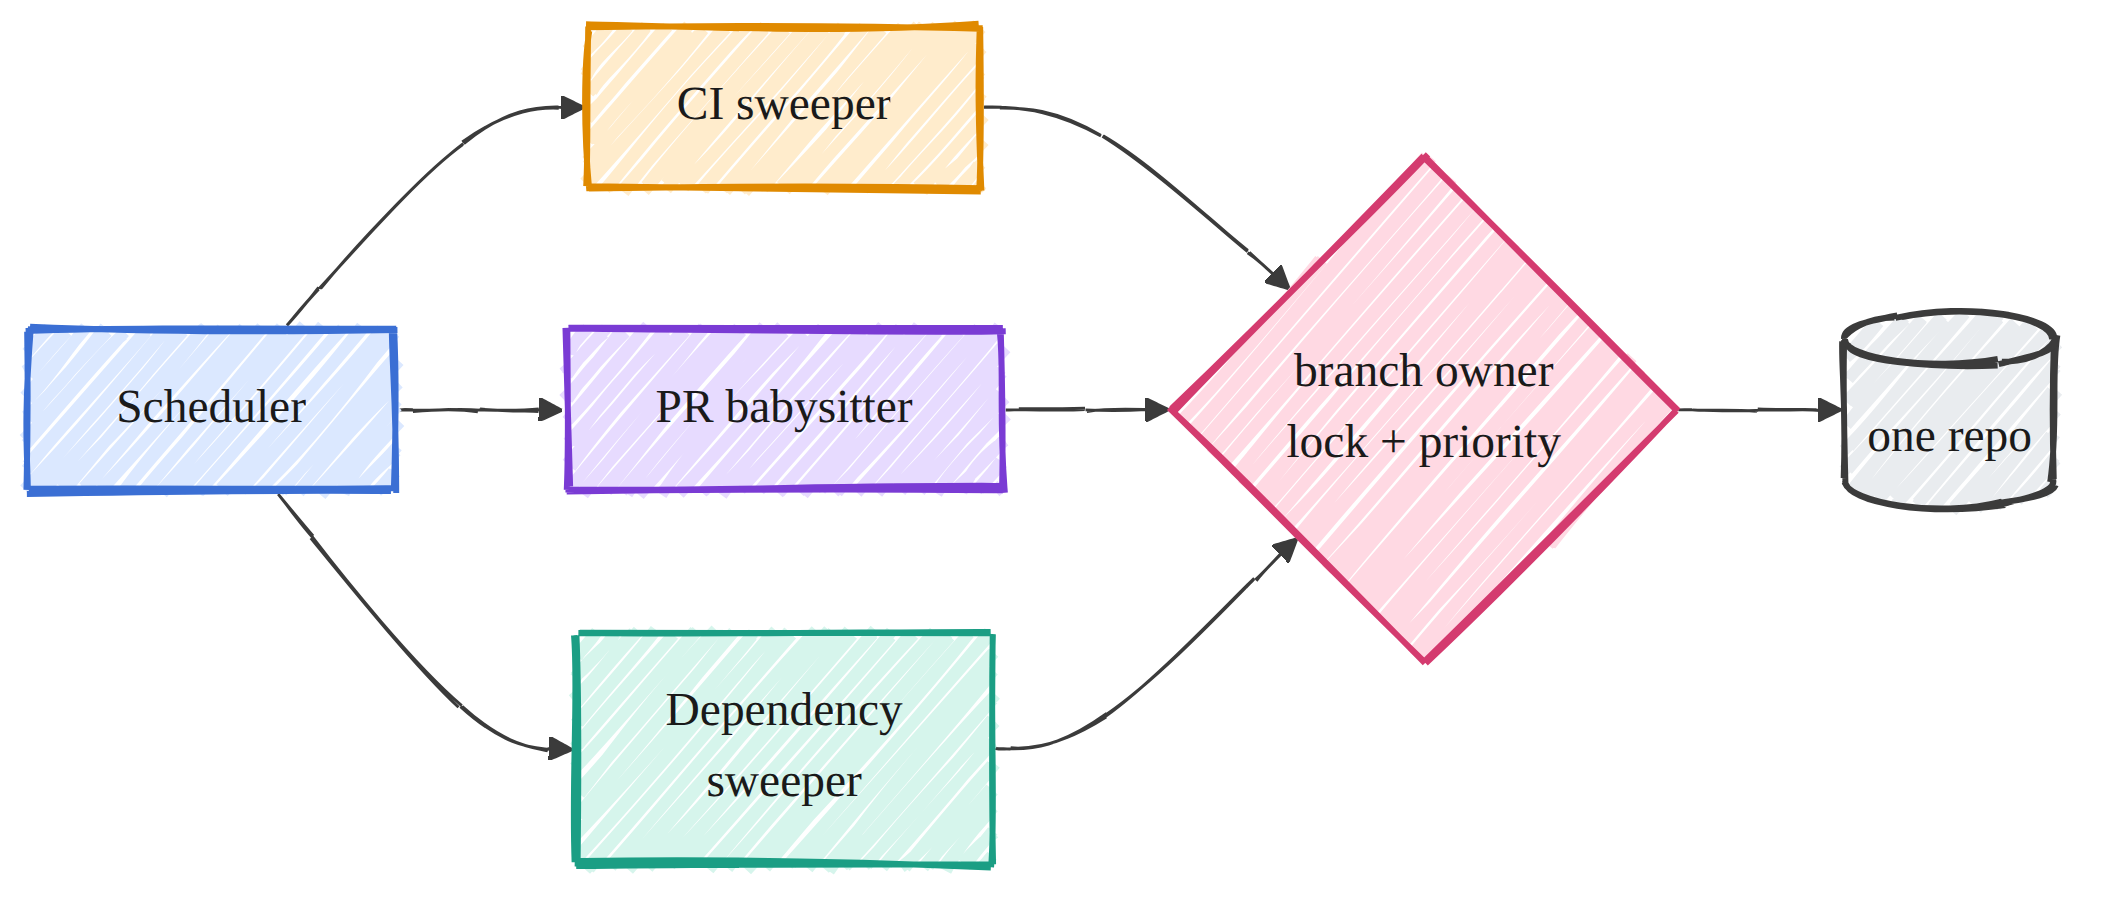


---------------------------------------- 작업 큐 (겹치는 대상에 주목) -----------------------------------------
  ci-sweeper (우선순위 1):       auth.py, api.py, utils.py, db.py
  pr-babysitter (우선순위 2):    api.py, ui.py, auth.py, tests.py
  dependency-sweeper (우선순위 3): db.py, utils.py, deps.txt, api.py


In [1]:
import os
import sys

sys.path.insert(0, os.environ.get("LEN_PROJECT_ROOT", os.path.abspath(".")))

from common import show, plotting, runlog, runtime

# ── 실행 환경 기록 ────────────────────────────────────────────────
# 이 노트북은 모델을 한 번도 호출하지 않는다. 충돌 수는 세 루프의 큐가
# 어떻게 겹치는지만으로 결정되므로 어느 백엔드에서 돌리든 같은 값이 나온다.
# 그래도 환경은 남겨 둔다 — 다른 노트북의 수치와 같은 실행에서 나온 것인지
# 대조하려면 필요하다. 백엔드가 없어도 이 노트북은 그대로 돈다.
try:
    rt = runtime.bootstrap()
    PROVIDER = rt.llm.provider
except Exception:
    rt, PROVIDER = None, "none (모델 호출 없음)"

show.head("루프 셋, 저장소 하나")
show.diagram("multi_loop", "각 루프가 acting_on 으로 대상을 클레임한다. 동점은 우선순위가 가른다. 브랜치마다 소유자는 하나다")

# ── 세 루프와 우선순위 ────────────────────────────────────────────
# priority 는 숫자가 작을수록 높다. 이 전순서(total order)가 있어야 중재가
# '정책' 이 된다. 순서를 주지 않고 먼저 도착한 쪽이 이기게 하면 그것은
# 중재가 아니라 경쟁이고, 실행마다 결과가 달라진다.
LOOPS = [
    {"name": "ci-sweeper", "priority": 1, "queue": ["auth.py", "api.py", "utils.py", "db.py"]},
    {"name": "pr-babysitter", "priority": 2, "queue": ["api.py", "ui.py", "auth.py", "tests.py"]},
    {"name": "dependency-sweeper", "priority": 3, "queue": ["db.py", "utils.py", "deps.txt", "api.py"]},
]

# 액션 1건 = 구현자 1회 + 검증기 1회. 이 코스의 액션 원가표에서 가져온 값이다.
# ⚠️ 함정: 이 단가를 낮게 잡으면 조율의 가치가 통째로 사라져 보인다. 충돌
#    건수는 단가와 무관하지만 '낭비된 토큰' 은 단가에 정비례하기 때문이다.
#    조율 계층을 도입할지 말지의 판단은 언제나 이 숫자에 걸려 있다.
TOKENS_PER_ACTION = 200_000

# 겹치는 지점: api.py (세 루프 전부), auth.py (ci+pr), utils.py (ci+dep), db.py (ci+dep)
show.sub("작업 큐 (겹치는 대상에 주목)")
for L in LOOPS:
    show.kv(f"{L['name']} (우선순위 {L['priority']})", ", ".join(L["queue"]))

## 조율이 없을 때

각 루프가 라운드 단위로 자기 큐를 처리한다. 두 루프가 같은 라운드에 같은 파일을 건드리면 그것이 **충돌**이다. 둘 다 실제로 작업을 하고(중복 토큰), 같은 브랜치 위에서 서로 경쟁하게 된다.


In [2]:
def run_uncoordinated(loops):
    """조율 없는 실행: 각 루프가 자기 큐를 전부 실행한다.

    어떤 루프도 남이 무엇을 하는지 모르므로, 두 개 이상의 큐에 있는 대상은
    그 큐 수만큼 중복 실행된다. 중복 작업이자 같은 브랜치 위의 경쟁이다.
    """
    from collections import Counter

    all_targets = [t for L in loops for t in L["queue"]]
    counts = Counter(all_targets)
    actions = len(all_targets)
    # ⚠️ 함정: 낭비를 '겹친 대상의 개수' 로 세면 안 된다. api.py 처럼 세 큐에
    #    걸친 대상은 대상 1개지만 중복은 2건이다. 반드시 (c - 1) 의 합으로
    #    세야 한다. 대상 수로 세면 이 실험에서 5 대신 4가 나오고, 청구서가
    #    20만 토큰만큼 조용히 축소된다.
    duplicate_actions = sum(c - 1 for c in counts.values())
    log = [f"  {t}: {c}개 루프가 작업 ({c - 1}건 중복 / 충돌)" for t, c in counts.items() if c > 1]
    return {"collisions": duplicate_actions, "actions": actions, "duplicate_actions": duplicate_actions, "log": log}


unc = run_uncoordinated(LOOPS)
show.head("조율 없는 결과")
for line in unc["log"]:
    print(line)
show.metric("충돌", unc["collisions"])
show.metric("총 액션", unc["actions"])
# 낭비된 토큰이 이 노트북의 주 지표다. 충돌 건수는 사건 수일 뿐,
# 그 사건이 얼마짜리인지는 단가를 곱해야 나온다.
show.metric("중복(낭비) 액션", unc["duplicate_actions"])
show.metric("낭비된 토큰", unc["duplicate_actions"] * TOKENS_PER_ACTION)


============================================= 조율 없는 결과 =============================================
  auth.py: 2개 루프가 작업 (1건 중복 / 충돌)
  api.py: 3개 루프가 작업 (2건 중복 / 충돌)
  utils.py: 2개 루프가 작업 (1건 중복 / 충돌)
  db.py: 2개 루프가 작업 (1건 중복 / 충돌)
  충돌                               5
  총 액션                             12
  중복(낭비) 액션                        5
  낭비된 토큰                           1000000


## 조율 프로토콜을 켰을 때

루프는 대상에 착수하기 전에 공유 `acting_on` 레지스트리를 확인한다. 더 높은 우선순위의 루프가 이번 라운드에 이미 그 대상을 클레임했다면, 그 루프는 **양보한다.** 건너뛰고 나중을 위해 다시 큐에 넣으며, 중복 작업은 하지 않는다. **라운드마다 대상 하나에 소유자 하나다.**


In [3]:
def run_coordinated(loops):
    """조율 실행: 대상마다 소유자 하나.

    공유 레지스트리를 통해 우선순위로 중재한다. 대상에 가장 먼저 닿은
    (= 가장 높은 우선순위의) 루프가 그것을 소유하고, 같은 대상을 큐에 가진
    낮은 우선순위 루프는 이미 소유된 것을 보고 작업을 되풀이하는 대신 놓는다.
    """
    # ⚠️ 함정: 이 정렬이 프로토콜의 전부다. 정렬을 빼면 딕셔너리에 먼저 닿은
    #    쪽이 이기게 되고, 그것은 중재가 아니라 경쟁이다. 충돌 수는 여전히
    #    0으로 나오므로 지표만 보면 정상으로 보이지만, 승자가 정책이 아니라
    #    리스트 순서로 정해진다 — 조용히 망가진 프로토콜의 전형이다.
    loops = sorted(loops, key=lambda L: L["priority"])
    owned_by = {}  # 대상 -> 소유한 루프
    actions = 0
    yielded = 0
    log = []
    for L in loops:
        for t in L["queue"]:
            if t in owned_by:
                # 양보는 취소가 아니다. 원 프로토콜에서는 다음 라운드로
                # 다시 큐잉된다. 여기서는 단일 라운드만 재므로 세기만 한다.
                yielded += 1
                log.append(f"  {L['name']} 가 {t} 를 양보 (소유: {owned_by[t]}, 더 높은 우선순위)")
            else:
                # 클레임은 토큰을 쓰기 '전' 에 일어난다. 절약이 사후 환불이
                # 아니라 사전 회피인 이유가 이 한 줄의 위치에 있다.
                owned_by[t] = L["name"]
                actions += 1
    return {"collisions": 0, "actions": actions, "yielded": yielded, "log": log}


cor = run_coordinated(LOOPS)
show.head("조율된 결과")
for line in cor["log"][:12]:
    print(line)
show.metric("충돌", cor["collisions"])
show.metric("고유 액션 (중복 없음)", cor["actions"])
show.metric("양보 (회피한 중복 작업)", cor["yielded"])
show.metric("낭비된 토큰", 0)


============================================== 조율된 결과 ==============================================
  pr-babysitter 가 api.py 를 양보 (소유: ci-sweeper, 더 높은 우선순위)
  pr-babysitter 가 auth.py 를 양보 (소유: ci-sweeper, 더 높은 우선순위)
  dependency-sweeper 가 db.py 를 양보 (소유: ci-sweeper, 더 높은 우선순위)
  dependency-sweeper 가 utils.py 를 양보 (소유: ci-sweeper, 더 높은 우선순위)
  dependency-sweeper 가 api.py 를 양보 (소유: ci-sweeper, 더 높은 우선순위)
  충돌                               0
  고유 액션 (중복 없음)                    7
  양보 (회피한 중복 작업)                   5
  낭비된 토큰                           0


## 비교와 시각화


  충돌: 조율 vs 무조율
    baseline : 5.0000
    treatment: 0.0000
    delta    : -5.0000  (-100.0 percent)  [down, improvement]


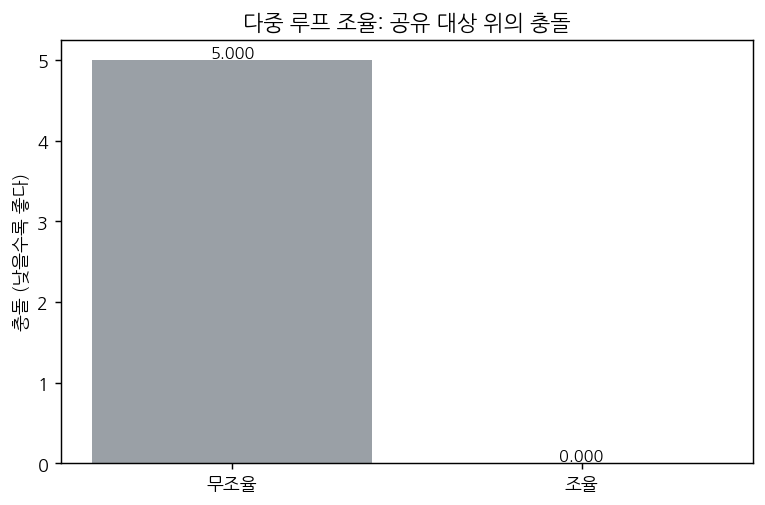

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/07_collisions.png


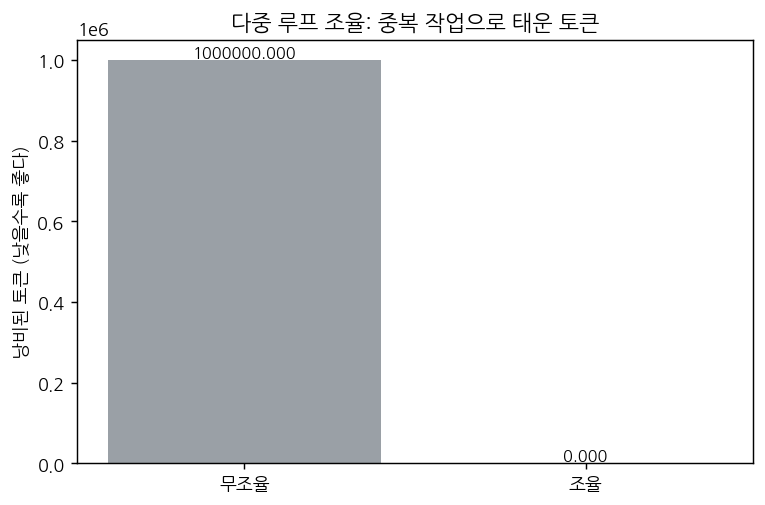

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/07_wasted_tokens.png
  saved metrics -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/07_multi_loop.json
  logged run -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/loop-run-log.json (multi-loop: report-only, ~0 tokens)


{'run_id': '2026-08-19T06:39:45Z',
 'pattern': 'multi-loop',
 'duration_s': 0.0,
 'items_found': 12,
 'actions_taken': 7,
 'escalations': 0,
 'tokens_estimate': 0,
 'outcome': 'report-only'}

In [4]:
# higher_is_better=False — 충돌은 적을수록 좋다. 이 인자를 빠뜨리면
# show.compare 가 개선 방향을 거꾸로 읽어 '100퍼센트 악화' 로 보고한다.
show.compare("충돌: 조율 vs 무조율", unc["collisions"], cor["collisions"], higher_is_better=False)

# 막대를 두 벌 그린다. 충돌 그래프는 '몇 번' 을, 토큰 그래프는 '얼마' 를
# 말한다. 후자가 없으면 이 노트북의 주장이 절반만 전달된다.
plotting.ab_bar("07_collisions", ["무조율", "조율"], [unc["collisions"], cor["collisions"]],
                "충돌 (낮을수록 좋다)", "다중 루프 조율: 공유 대상 위의 충돌")
plotting.ab_bar("07_wasted_tokens", ["무조율", "조율"],
                [unc["duplicate_actions"] * TOKENS_PER_ACTION, 0],
                "낭비된 토큰 (낮을수록 좋다)", "다중 루프 조율: 중복 작업으로 태운 토큰")

runlog.save_metrics("07_multi_loop", {
    "notebook": "07_multi_loop", "loops": [L["name"] for L in LOOPS],
    "provider": PROVIDER,        # 한국어판 추가: 어느 실행 환경의 수치인지 기록
    "uncoordinated_collisions": unc["collisions"], "coordinated_collisions": cor["collisions"],
    "wasted_tokens_uncoordinated": unc["duplicate_actions"] * TOKENS_PER_ACTION,
    # 양보 수도 함께 남긴다. 충돌 0만 저장하면 "겹침이 애초에 없었다" 와
    # "겹침을 중재했다" 를 나중에 구별할 수 없다.
    "yields": cor["yielded"],
})
runlog.log_run(pattern="multi-loop", duration_s=0, items_found=unc["actions"],
               actions_taken=cor["actions"], escalations=0, tokens_estimate=0, outcome="report-only")

## 이번 실행이 실제로 보여 준 것


In [5]:
show.head("이번 실행이 실제로 보여 준 것")
print(f"무조율: 공유 파일 위에서 충돌 {unc['collisions']}건, 중복 액션 {unc['duplicate_actions']}건,")
print(f"  같은 작업을 다시 하는 데 약 {unc['duplicate_actions'] * TOKENS_PER_ACTION:,} 토큰을 낭비했다 (그리고 브랜치 경쟁).")
print(f"조율: 충돌 {cor['collisions']}건. 충돌하는 대신 우선순위로 양보한 횟수 {cor['yielded']}건.")
print()
print("=> acting_on 락에 우선순위 순서를 더하면, 저장소 하나를 놓고 다투던 루프 셋이")
print("   대상마다 소유자 하나인 상태로 바뀐다. 이것이 여러 루프를 한 저장소에서")
print("   안전하게 돌리게 해 주는 조율 계층이며, 루프 하나 안의 서브에이전트를")
print("   격리하는 워크트리와는 층이 다르다.")


======================================== 이번 실행이 실제로 보여 준 것 =========================================
무조율: 공유 파일 위에서 충돌 5건, 중복 액션 5건,
  같은 작업을 다시 하는 데 약 1,000,000 토큰을 낭비했다 (그리고 브랜치 경쟁).
조율: 충돌 0건. 충돌하는 대신 우선순위로 양보한 횟수 5건.

=> acting_on 락에 우선순위 순서를 더하면, 저장소 하나를 놓고 다투던 루프 셋이
   대상마다 소유자 하나인 상태로 바뀐다. 이것이 여러 루프를 한 저장소에서
   안전하게 돌리게 해 주는 조율 계층이며, 루프 하나 안의 서브에이전트를
   격리하는 워크트리와는 층이 다르다.
